Датасет подготовлен

Обучение на: cuda:0

Классы для классификации: ['ants', 'bees']

Эпоха 1/5
----------
train Loss: 0.6486 Acc: 0.7664
val Loss: 16.8009 Acc: 0.6214

Эпоха 2/5
----------
train Loss: 0.5327 Acc: 0.7705
val Loss: 3.8223 Acc: 0.6505

Эпоха 3/5
----------
train Loss: 0.4377 Acc: 0.8033
val Loss: 5.5765 Acc: 0.6699

Эпоха 4/5
----------
train Loss: 0.4254 Acc: 0.8320
val Loss: 1.5432 Acc: 0.7184

Эпоха 5/5
----------
train Loss: 0.3749 Acc: 0.8402
val Loss: 0.8630 Acc: 0.7767

Итоговая точность на тестовой выборке (50 изображений): 0.7200



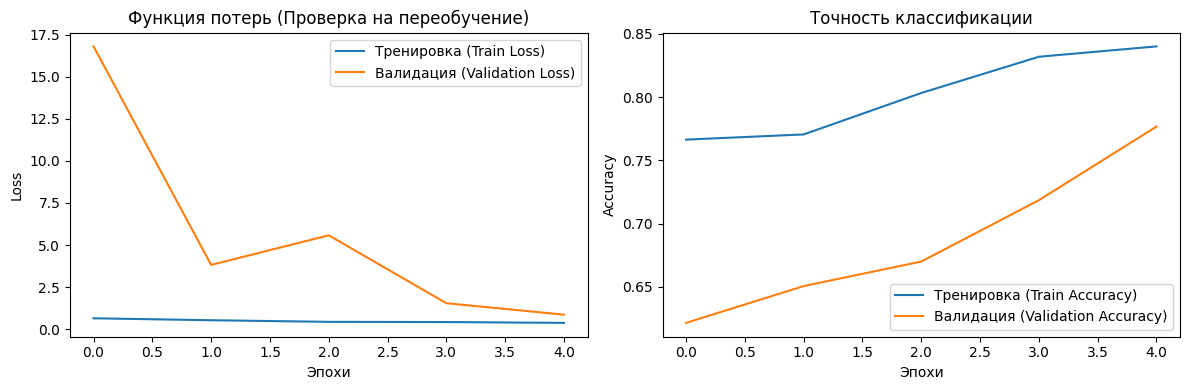

In [5]:
import os
import zipfile
import urllib.request
import shutil
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt

url = 'https://download.pytorch.org/tutorial/hymenoptera_data.zip'
zip_path = 'hymenoptera_data.zip'
data_dir = 'hymenoptera_data'

if not os.path.exists(data_dir):
    print("Загрузка датасета Ants vs Bees...")
    req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
    with urllib.request.urlopen(req) as response, open(zip_path, 'wb') as out_file:
        shutil.copyfileobj(response, out_file)

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall()

    print("Подготовка данных для test (50 изображений)")
    os.makedirs(os.path.join(data_dir, 'test', 'ants'), exist_ok=True)
    os.makedirs(os.path.join(data_dir, 'test', 'bees'), exist_ok=True)

    for category in ['ants', 'bees']:
        val_cat_dir = os.path.join(data_dir, 'val', category)
        test_cat_dir = os.path.join(data_dir, 'test', category)

        images = os.listdir(val_cat_dir)[:25]
        for img in images:
            shutil.move(os.path.join(val_cat_dir, img), os.path.join(test_cat_dir, img))

print("Датасет подготовлен\n")

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Обучение на: {device}\n")

data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x])
                  for x in ['train', 'val', 'test']}

dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=32, shuffle=True)
               for x in ['train', 'val', 'test']}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val', 'test']}
class_names = image_datasets['train'].classes
print(f"Классы для классификации: {class_names}\n")

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(class_names))
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 5
train_losses, val_losses, train_accs, val_accs = [], [], [], []

for epoch in range(num_epochs):
    print(f'Эпоха {epoch+1}/{num_epochs}')
    print('-' * 10)

    for phase in ['train', 'val']:
        if phase == 'train':
            model.train()
        else:
            model.eval()

        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in dataloaders[phase]:
            inputs = inputs.to(device)
            labels = labels.to(device)
            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / dataset_sizes[phase]
        epoch_acc = running_corrects.double() / dataset_sizes[phase]
        print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

        if phase == 'train':
            train_losses.append(epoch_loss)
            train_accs.append(epoch_acc.item())
        else:
            val_losses.append(epoch_loss)
            val_accs.append(epoch_acc.item())
    print()

model.eval()
test_corrects = 0
with torch.no_grad():
    for inputs, labels in dataloaders['test']:
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        test_corrects += torch.sum(preds == labels.data)

test_acc = test_corrects.double() / dataset_sizes['test']
print(f'Итоговая точность на тестовой выборке (50 изображений): {test_acc:.4f}\n')

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Тренировка (Train Loss)')
plt.plot(val_losses, label='Валидация (Validation Loss)')
plt.title('Функция потерь (Проверка на переобучение)')
plt.xlabel('Эпохи')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Тренировка (Train Accuracy)')
plt.plot(val_accs, label='Валидация (Validation Accuracy)')
plt.title('Точность классификации')
plt.xlabel('Эпохи')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()